<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Assignment28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1: Loading the Dataset

In [1]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("train.txt", sep=";", names=["text", "emotions"])

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 10 Rows:
                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love

Dataset Shape:
(16000, 2)

Missing Values:
text        0
emotions    0
dtype: int64


Q2.Exploring Target Labels (Label Encoding)

In [2]:
from sklearn.preprocessing import LabelEncoder

# Display unique labels
print("Unique Emotion Labels:")
print(df["emotions"].unique())

# Create LabelEncoder
label_encoder = LabelEncoder()

# Encode labels
df["emotion_encoded"] = label_encoder.fit_transform(df["emotions"])

# Create mapping
emotion_mapping = dict(zip(label_encoder.classes_,
                           label_encoder.transform(label_encoder.classes_)))

print("\nEmotion Mapping:")
print(emotion_mapping)

# Display first 10 rows
print("\nUpdated Dataset:")
print(df.head(10))

Unique Emotion Labels:
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Emotion Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

Updated Dataset:
                                                text  emotions  \
0                            i didnt feel humiliated   sadness   
1  i can go from feeling so hopeless to so damned...   sadness   
2   im grabbing a minute to post i feel greedy wrong     anger   
3  i am ever feeling nostalgic about the fireplac...      love   
4                               i am feeling grouchy     anger   
5  ive been feeling a little burdened lately wasn...   sadness   
6  ive been taking or milligrams or times recomme...  surprise   
7  i feel as confused about life as a teenager or...      fear   
8  i have been with petronas for years i feel tha...       joy   
9                                i feel romantic too      love   

   emotion_encoded  
0       

Q3 (Lowercasing).

In [3]:
# Save original text
df["original_text"] = df["text"]

# Convert to lowercase
df["text"] = df["text"].str.lower()

# Display comparison
print("Before and After Lowercasing:\n")
print(df[["original_text", "text"]].head(5))

Before and After Lowercasing:

                                       original_text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                                text  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


Q4 (Removing Punctuation).

In [4]:
import string

# Save original text before punctuation removal
df["before_punctuation"] = df["text"]

# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply function
df["text"] = df["text"].apply(remove_punctuation)

# Display comparison
print("Before and After Removing Punctuation:\n")
print(df[["before_punctuation", "text"]].head(5))

Before and After Removing Punctuation:

                                  before_punctuation  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                                text  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


Q5 (Removing Numbers).

In [5]:
import re

# Save text before removing numbers
df["before_numbers"] = df["text"]

# Function to remove numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Apply function
df["text"] = df["text"].apply(remove_numbers)

# Display comparison
print("Before and After Removing Numbers:\n")
print(df[["before_numbers", "text"]].head(5))

Before and After Removing Numbers:

                                      before_numbers  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                                text  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


Q6 (Removing Emojis & Special Characters).

In [6]:
# Save original text
df["before_emoji"] = df["text"]

# Function to remove emojis and special characters
def remove_emojis(text):
    return text.encode("ascii", "ignore").decode("ascii")

# Apply function
df["text"] = df["text"].apply(remove_emojis)

# Display comparison
print("Before and After Removing Emojis & Special Characters:\n")
print(df[["before_emoji", "text"]].head(5))

Before and After Removing Emojis & Special Characters:

                                        before_emoji  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                                text  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


Q7 (Removing Stopwords using NLTK).

In [7]:
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')

# Save original text
df["before_stopwords"] = df["text"]

# Create stopwords set
stop_words = set(stopwords.words("english"))

# Function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Apply function
df["text"] = df["text"].apply(remove_stopwords)

# Display comparison
print("Before and After Removing Stopwords:\n")
print(df[["before_stopwords", "text"]].head(5))

Before and After Removing Stopwords:

                                    before_stopwords  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                                text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Q8: Create a Complete Text Cleaning Function

In [8]:
import string
import re
from nltk.corpus import stopwords

# Create stopwords set
stop_words = set(stopwords.words("english"))

# Complete cleaning function
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove emojis
    text = text.encode("ascii", "ignore").decode("ascii")

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Create cleaned_text column
df["cleaned_text"] = df["text"].apply(clean_text)

# Display result
print(df[["text", "cleaned_text"]].head(5))

                                                text  \
0                              didnt feel humiliated   
1  go feeling hopeless damned hopeful around some...   
2          im grabbing minute post feel greedy wrong   
3  ever feeling nostalgic fireplace know still pr...   
4                                    feeling grouchy   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  


Q9 (Text Length Analysis).

Average Text Length : 61.6723125
Minimum Text Length : 4
Maximum Text Length : 232


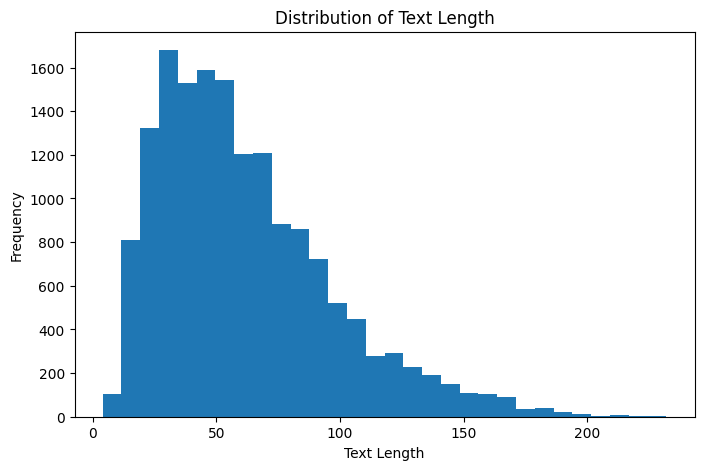

In [9]:
import matplotlib.pyplot as plt

# Create text length column
df["text_length"] = df["cleaned_text"].apply(len)

# Statistics
print("Average Text Length :", df["text_length"].mean())
print("Minimum Text Length :", df["text_length"].min())
print("Maximum Text Length :", df["text_length"].max())

# Histogram
plt.figure(figsize=(8,5))

plt.hist(df["text_length"], bins=30)

plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()

Q10.Mini Project: Complete NLP Preprocessing Pipeline

In [10]:
# Import required libraries
import pandas as pd
import string
import re
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder

# Download stopwords
nltk.download('stopwords')

# Load dataset
df = pd.read_csv("train.txt", sep=";", names=["text", "emotions"])

# Create LabelEncoder
label_encoder = LabelEncoder()
df["emotion_encoded"] = label_encoder.fit_transform(df["emotions"])

# Stopwords
stop_words = set(stopwords.words("english"))

# Complete cleaning function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove emojis & special characters
    text = text.encode("ascii", "ignore").decode("ascii")

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df["cleaned_text"] = df["text"].apply(clean_text)

# Save cleaned dataset
df.to_csv("cleaned_emotions.csv", index=False)

print("Dataset saved successfully as cleaned_emotions.csv")

# Emotion counts
print("\nEmotion Distribution:")
print(df["emotions"].value_counts())

# Display first 10 rows
print("\nFirst 10 Rows:")
print(df.head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset saved successfully as cleaned_emotions.csv

Emotion Distribution:
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

First 10 Rows:
                                                text  emotions  \
0                            i didnt feel humiliated   sadness   
1  i can go from feeling so hopeless to so damned...   sadness   
2   im grabbing a minute to post i feel greedy wrong     anger   
3  i am ever feeling nostalgic about the fireplac...      love   
4                               i am feeling grouchy     anger   
5  ive been feeling a little burdened lately wasn...   sadness   
6  ive been taking or milligrams or times recomme...  surprise   
7  i feel as confused about life as a teenager or...      fear   
8  i have been with petronas for years i feel tha...       joy   
9                                i feel romantic too      love   

   emotion_encoded                            